# 🧭 Matplotlib Complete Tutorial (with `tips` dataset)
---
A full guide on using **Matplotlib** for data visualization in Python using the **`tips`** dataset.


## 📘 1. Introduction to Matplotlib
**Matplotlib** is a powerful Python library for creating static, animated, and interactive visualizations.

It’s essential for:
- **Understanding data patterns visually**
- **Identifying trends and outliers**
- **Communicating insights effectively**

## 🧩 2. Installing & Importing

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 📊 3. Load the `tips` Dataset
This dataset contains restaurant tipping information:
- `total_bill`: total bill (USD)
- `tip`: tip given (USD)
- `sex`: gender of server
- `smoker`: smoker/non-smoker
- `day`: day of week
- `time`: lunch/dinner
- `size`: number of people

In [25]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## 🎯 4. Importance of Charts
| Chart Type | Purpose | Example |
|-------------|----------|----------|
| **Bar Chart** | Compare categories | Average tip by day |
| **Histogram** | Show distribution | Tip amount distribution |
| **Scatter Plot** | Relationship between variables | Bill vs. Tip |
| **Box Plot** | Detect outliers and spread | Tips by gender |
| **Pie Chart** | Show proportions | Male vs. Female customers |
| **Line Chart** | Trends over time | Not applicable here |

## 🍽️ 6. Visualizing the `tips` Dataset

### 6.1 Histogram — Distribution of Tips

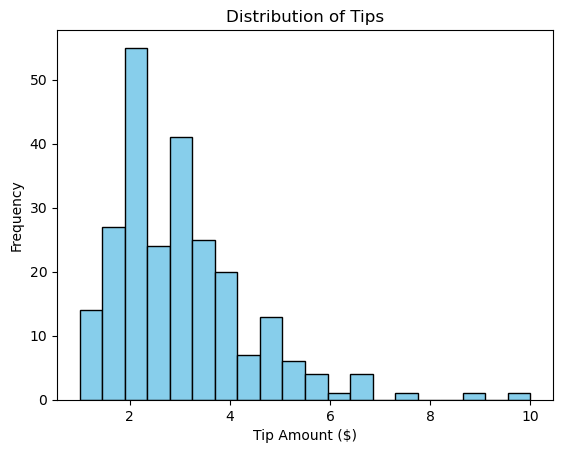

In [6]:
plt.hist(tips['tip'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Tips')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.show()

### 6.2 Bar Chart — Average Tip by Day

C:\Users\MiMic\AppData\Local\Temp\ipykernel_25372\2687948128.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_day = tips.groupby('day')['tip'].mean()


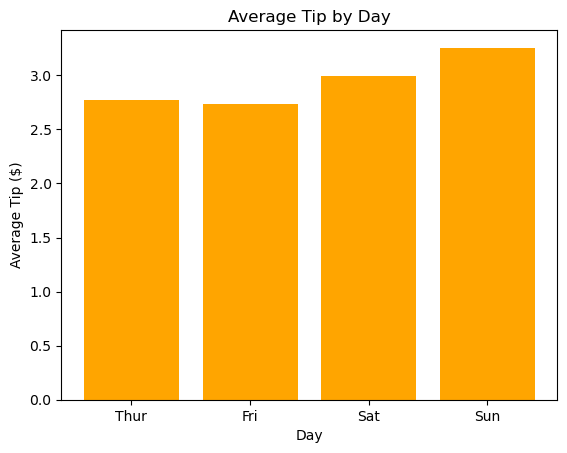

In [7]:
avg_tip_by_day = tips.groupby('day')['tip'].mean()
plt.bar(avg_tip_by_day.index, avg_tip_by_day.values, color='orange')
plt.title('Average Tip by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip ($)')
plt.show()

### 6.3 Scatter Plot — Total Bill vs. Tip

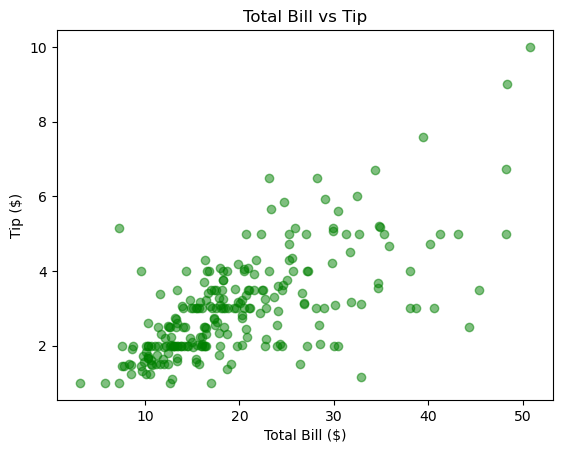

In [9]:
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.5, color='green')
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

C:\Users\MiMic\AppData\Local\Temp\ipykernel_26280\4020781220.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tips['total_bill'], tips['tip'], tips['size']], labels=['total_bill', 'tip', 'size'])


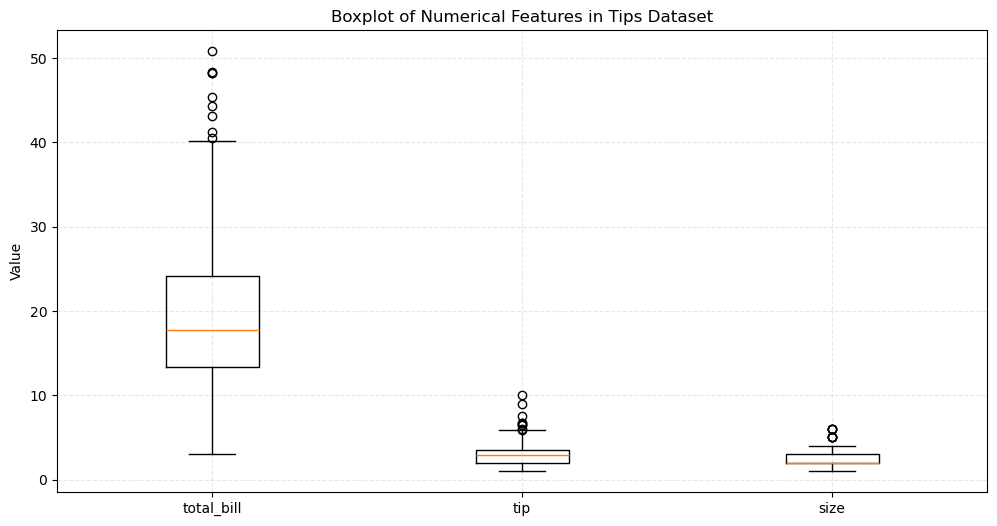

In [10]:
plt.figure(figsize=(12,6))
plt.boxplot([tips['total_bill'], tips['tip'], tips['size']], labels=['total_bill', 'tip', 'size'])
plt.title("Boxplot of Numerical Features in Tips Dataset")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### 6.4 Box Plot — Tips by Gender

In [11]:
tips[tips['sex']=='Male']['tip']

1      1.66
2      3.50
3      3.31
5      4.71
6      2.00
       ... 
236    1.00
237    1.17
239    5.92
241    2.00
242    1.75
Name: tip, Length: 157, dtype: float64

C:\Users\MiMic\AppData\Local\Temp\ipykernel_26280\3745965652.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


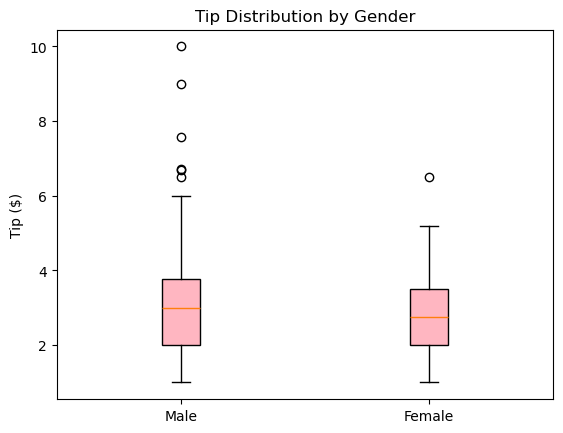

In [12]:
plt.boxplot([
    tips[tips['sex']=='Male']['tip'],
    tips[tips['sex']=='Female']['tip']
], labels=['Male', 'Female'], patch_artist=True,
boxprops=dict(facecolor='lightpink'))
plt.title('Tip Distribution by Gender')
plt.ylabel('Tip ($)')
plt.show()

### 6.5 Pie Chart — Gender Distribution

In [12]:
gender_counts = tips['sex'].value_counts()
gender_counts

sex
Male      157
Female     87
Name: count, dtype: int64

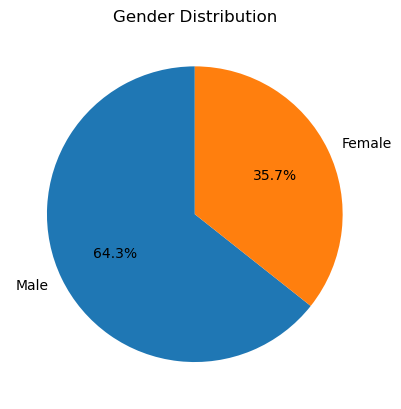

In [13]:
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

## 🧠 7. Enhancing Visuals

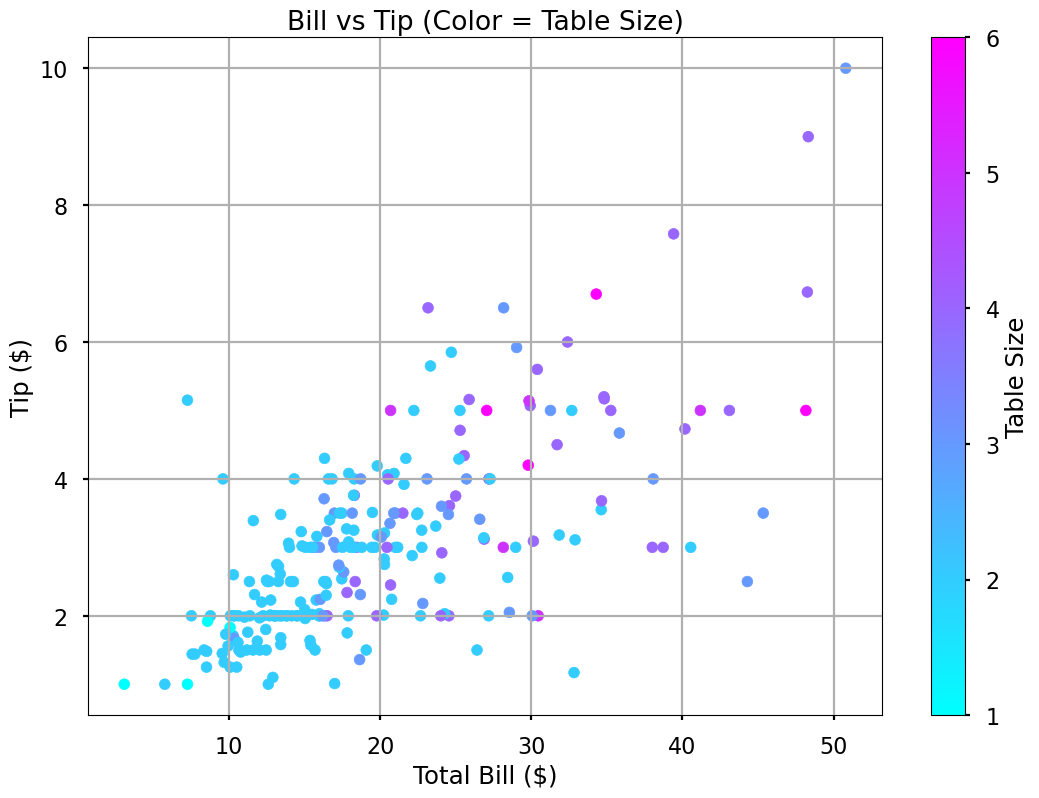

In [14]:
plt.style.use('seaborn-v0_8-poster')
plt.scatter(tips['total_bill'], tips['tip'], c=tips['size'], cmap='cool', s=60)
plt.colorbar(label='Table Size')
plt.title('Bill vs Tip (Color = Table Size)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True)
plt.show()

## 🔍 8. Subplots — Multiple Charts Together

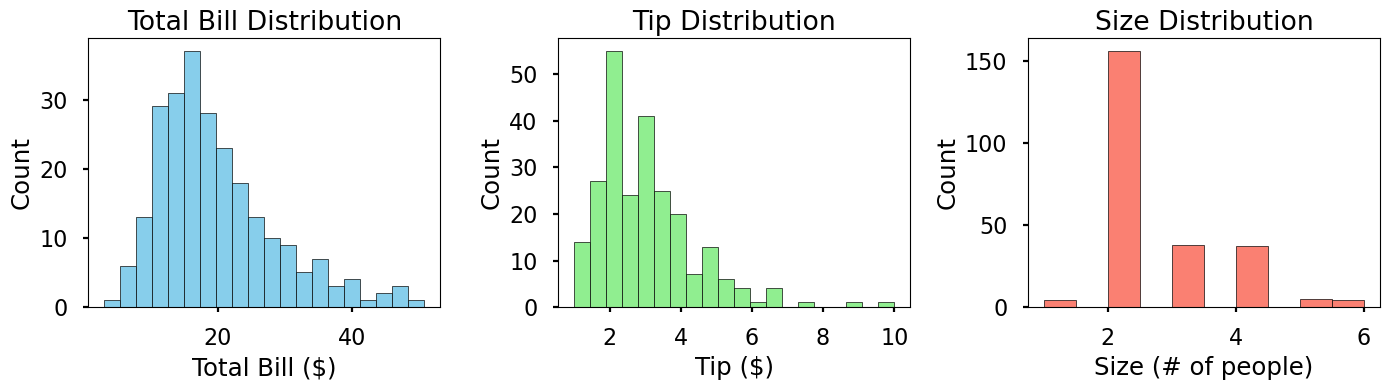

In [15]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.hist(tips['total_bill'], bins=20, color='skyblue', edgecolor='black')
plt.title('Total Bill Distribution')
plt.xlabel('Total Bill ($)')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(tips['tip'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Tip Distribution')
plt.xlabel('Tip ($)')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist(tips['size'], bins=10, color='salmon', edgecolor='black')
plt.title('Size Distribution')
plt.xlabel('Size (# of people)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

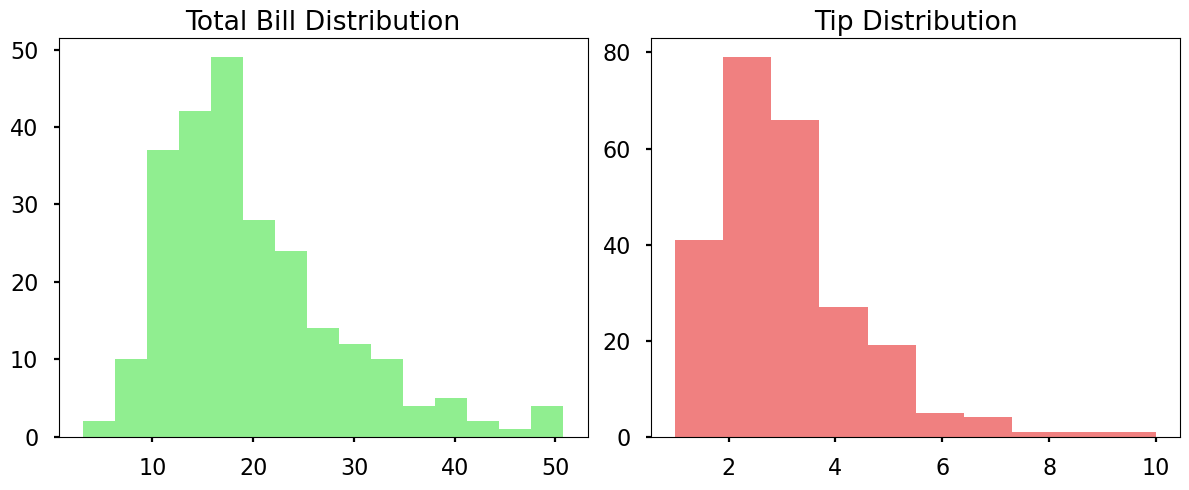

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(tips['total_bill'], bins=15, color='lightgreen')
axes[0].set_title('Total Bill Distribution')
axes[1].hist(tips['tip'], bins=10, color='lightcoral')
axes[1].set_title('Tip Distribution')
plt.tight_layout()
plt.show()

## 🧮 9. Correlation Visualization

In [26]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [27]:
corr = tips.corr(numeric_only=True)
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [28]:
tips["sex"].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [29]:
def encode(sex):
    if sex == "Male":
        return 0
    else:
        return 1

In [30]:
tips["sex"] = tips["sex"].apply(encode)

In [31]:
def Encode_day(day):
    if day == "Sun":
        return 3
    elif day == "Sat":
        return 2
    else: 
        return 1

In [32]:
tips["day"] = tips["day"].apply(Encode_day)

In [33]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,No,3,Dinner,2
1,10.34,1.66,0,No,3,Dinner,3
2,21.01,3.50,0,No,3,Dinner,3
3,23.68,3.31,0,No,3,Dinner,2
4,24.59,3.61,1,No,3,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,0,No,2,Dinner,3
240,27.18,2.00,1,Yes,2,Dinner,2
241,22.67,2.00,0,Yes,2,Dinner,2
242,17.82,1.75,0,No,2,Dinner,2


In [34]:
corr = tips.corr(numeric_only=True)
corr

,total_bill,tip,day,size
total_bill,1.000000,0.675734,0.174817,0.598315
tip,0.675734,1.000000,0.142842,0.489299
day,0.174817,0.142842,1.000000,0.198418
size,0.598315,0.489299,0.198418,1.000000


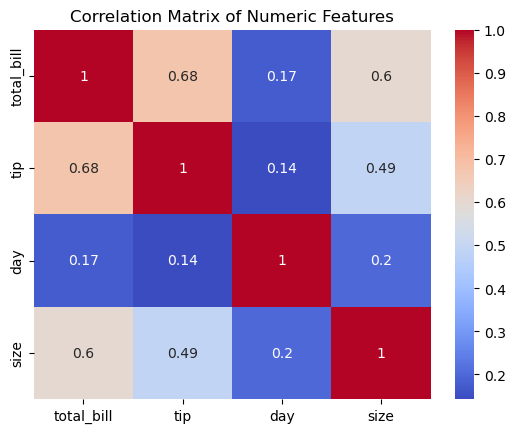

In [35]:
corr = tips.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## 💡 10. Why Charts Matter in Data Analysis
| Purpose | Benefit |
|----------|----------|
| **Pattern Recognition** | Quickly identify relationships |
| **Decision Support** | Easier to justify conclusions |
| **Outlier Detection** | Spot anomalies visually |
| **Simplify Complexity** | Communicate insights clearly |
| **Validation** | Confirm trends visually |

## 🧾 11. Summary
| Concept | Example |
|----------|----------|
| Line Plot | General trend |
| Bar Chart | Categorical comparison |
| Histogram | Frequency distribution |
| Scatter Plot | Relationship between 2 variables |
| Box Plot | Spread & outliers |
| Pie Chart | Proportions |
| Subplots | Multi-view comparison |

## ✅ 12. Mini Project — Tip Behavior Analysis

C:\Users\MiMic\AppData\Local\Temp\ipykernel_25372\3224751915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = tips.groupby(['sex', 'smoker'])['tip'].mean().unstack()


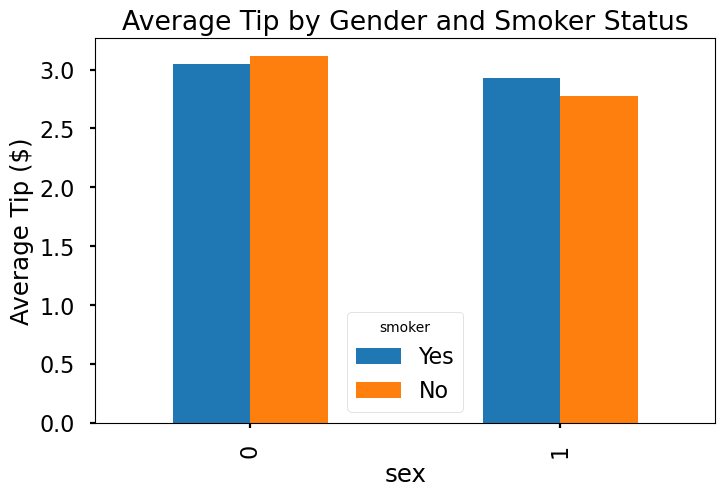

In [25]:
grouped = tips.groupby(['sex', 'smoker'])['tip'].mean().unstack()
grouped.plot(kind='bar', figsize=(8,5))
plt.title('Average Tip by Gender and Smoker Status')
plt.ylabel('Average Tip ($)')
plt.show()